**1. L1 Normalization (Least Absolute Deviations)**

Also known as **Manhattan Norm** or **Least Absolute Shrinkage**, L1 normalization **scales** each row (sample) such that the **sum of absolute values** equals 1.

**Formula:**

$$
x_{\text{norm}} = \frac{x}{\|x\|_1} = \frac{x}{\sum |x_i|}
$$

**Use Cases:**

* When **sparse features** are important.
* In **text classification** (e.g., TF-IDF vectors).






**Import Libraries**

In [1]:
import pandas as pd
from sklearn.preprocessing import Normalizer

In [2]:
df= pd.read_csv("00_raw_data/bank-loan.csv")
df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


**Separate Features & Target**

In [3]:
X = df.drop('default', axis=1)
y = df['default']

**L1 Normalization**

In [4]:
l1_norm = Normalizer(norm='l1')
X_l1 = l1_norm.fit_transform(X)

In [5]:
X_l1 = pd.DataFrame(X_l1, columns=X.columns)

X_l1.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt
0,0.149271,0.010922,0.061893,0.043689,0.640774,0.033859,0.041357,0.018235
1,0.276461,0.010239,0.102393,0.061436,0.317418,0.177140,0.013948,0.040965
2,0.299569,0.007489,0.112339,0.104849,0.411908,0.041191,0.006411,0.016244
3,0.207721,0.005066,0.075996,0.070929,0.607964,0.014692,0.013470,0.004161
4,0.307125,0.025594,0.025594,0.000000,0.358313,0.221386,0.022874,0.039115


In [6]:
print(X_l1.iloc[0].abs().sum())

1.0


**2. L2 Normalization (Least Squares)**

Also known as **Euclidean Norm**, L2 normalization scales each row such that the **sum of squared values equals 1**.

**Formula:**

$$
x_{\text{norm}} = \frac{x}{\|x\|_2} = \frac{x}{\sqrt{\sum x_i^2}}
$$

**Use Cases:**

* When **distance-based algorithms** (like KNN, SVM) are used.
* For **gradient descent convergence**.


In [7]:
l2_norm = Normalizer(norm='l2')
X_l2 = l2_norm.fit_transform(X)

In [8]:
X_l2 = pd.DataFrame(X_l2, columns=X.columns)

X_l2.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt
0,0.224545,0.016430,0.093104,0.065721,0.963901,0.050933,0.062212,0.027431
1,0.583091,0.021596,0.215959,0.129576,0.669474,0.373610,0.029418,0.086401
2,0.561065,0.014027,0.210399,0.196373,0.771465,0.077146,0.012008,0.030423
3,0.318999,0.007780,0.116707,0.108927,0.933657,0.022563,0.020686,0.006390
4,0.585570,0.048798,0.048798,0.000000,0.683165,0.422098,0.043611,0.074576


In [9]:
import numpy as np
print(np.sqrt((X_l2.iloc[0]**2).sum()))

1.0


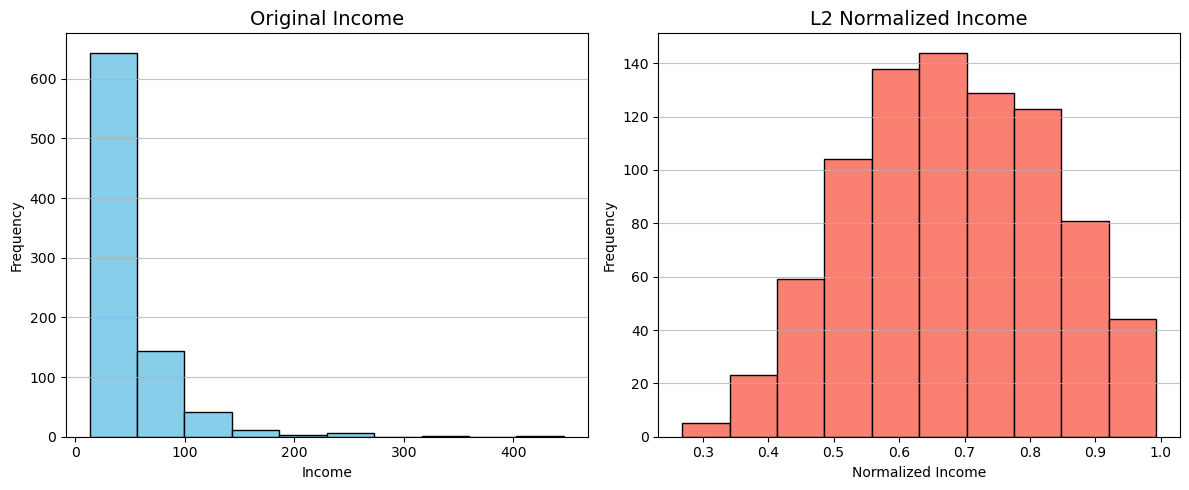

In [10]:
import matplotlib.pyplot as plt

# 2 plots ek sathe
plt.figure(figsize=(12,5))

# Original Income
plt.subplot(1,2,1)
plt.hist(X['income'], bins=10, color='skyblue', edgecolor='black')
plt.title("Original Income", fontsize=14)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)

# L2 Normalized Income
plt.subplot(1,2,2)
plt.hist(X_l2['income'], bins=10, color='salmon', edgecolor='black')
plt.title("L2 Normalized Income", fontsize=14)
plt.xlabel("Normalized Income")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()